In [82]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
import datetime as dt
import warnings
warnings.filterwarnings('ignore')

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor




[*********************100%***********************]  4 of 4 completed


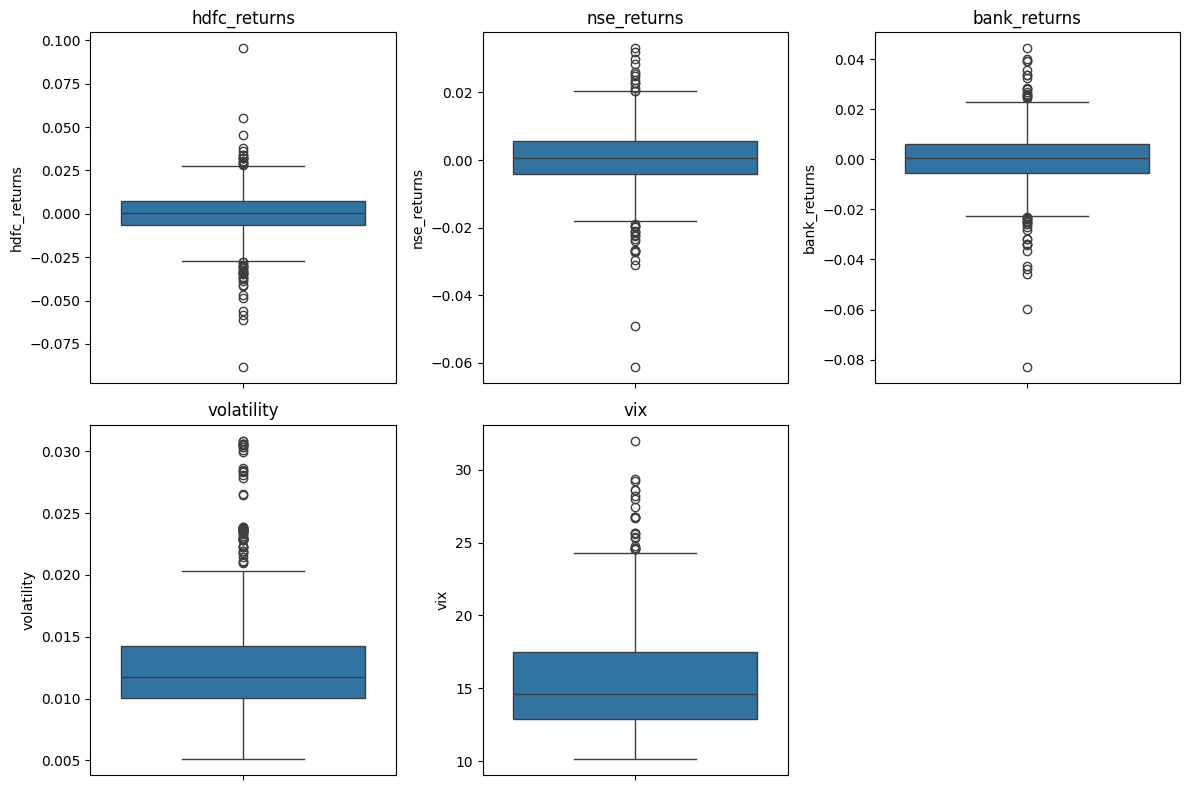

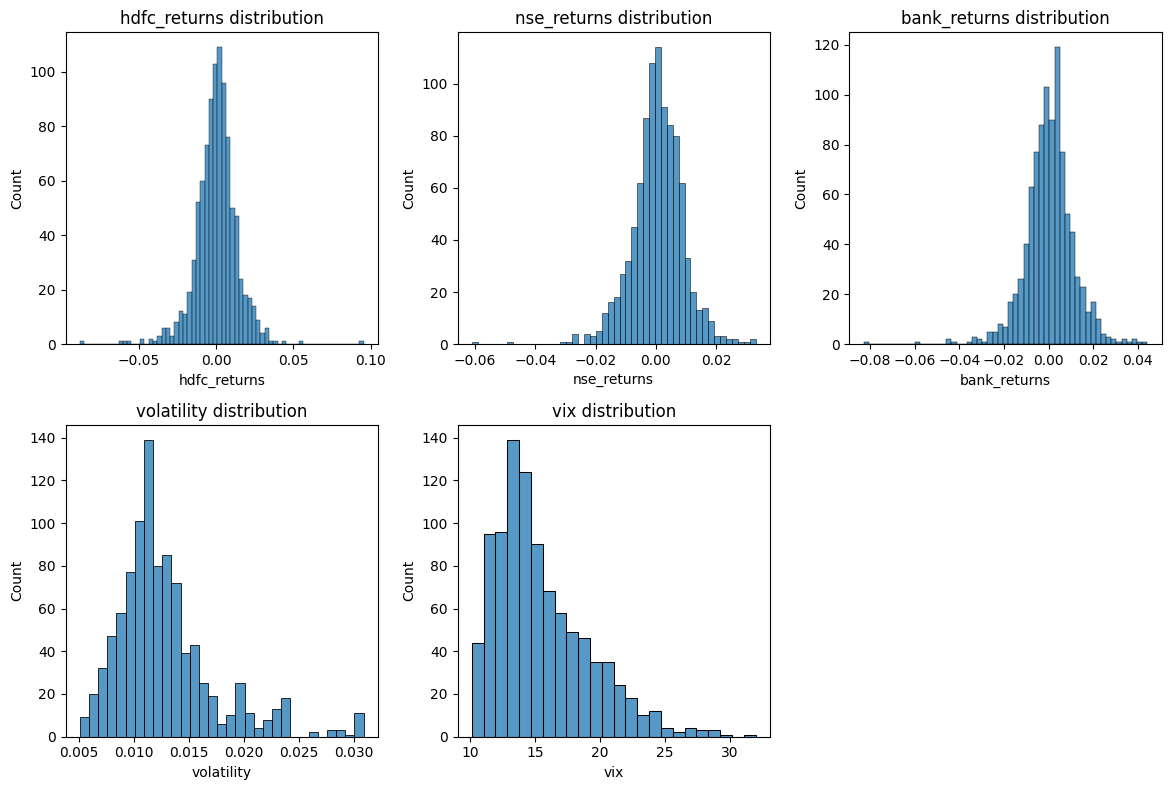

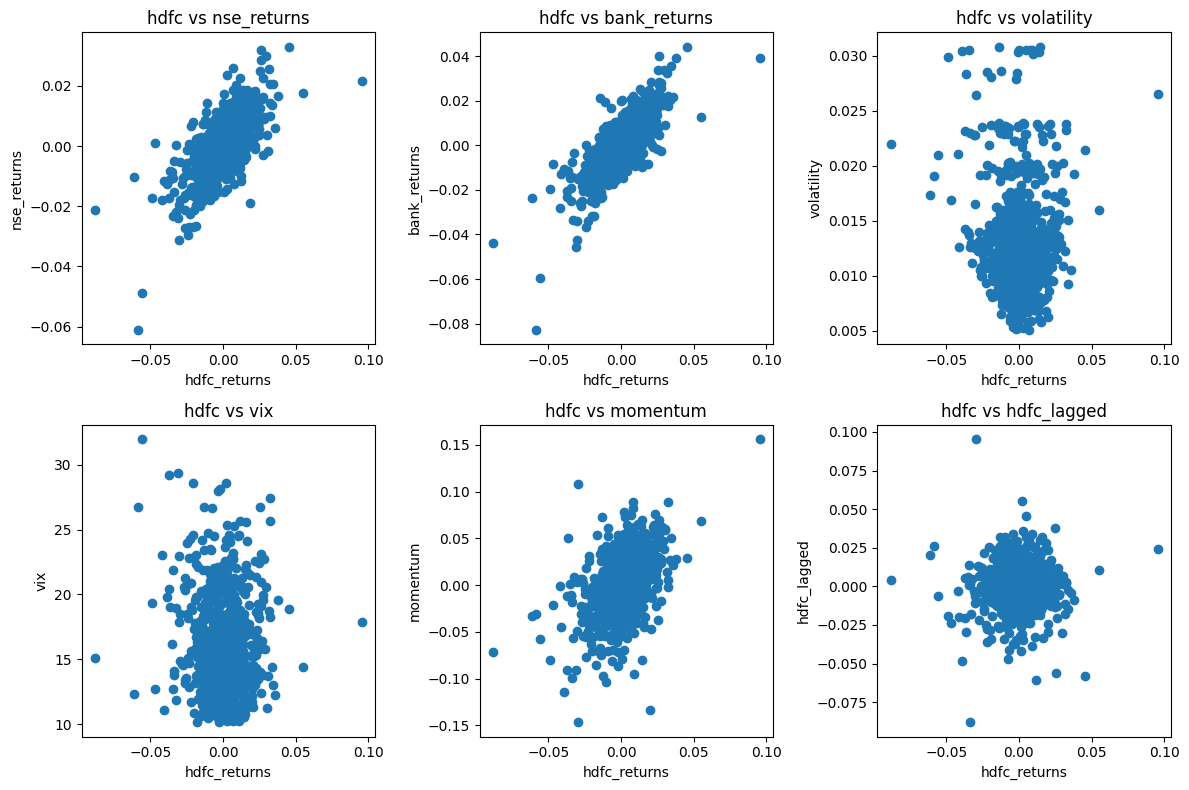

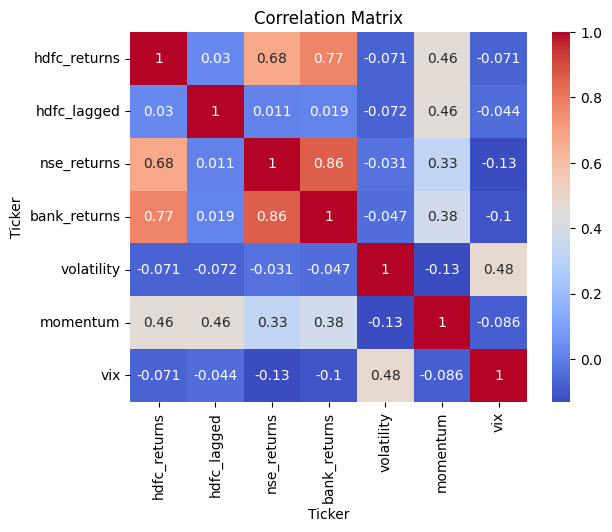

In [83]:
end = dt.date.today()
start = dt.date.today() - dt.timedelta(days=365*5)
ticker = ['HDFCBANK.NS','^NSEI','^INDIAVIX','^NSEBANK']
df = yf.download(tickers=ticker,start=start,end=end,auto_adjust=True)['Close']

# Dropping Nans
df[df.isna().any(axis=1)]
df.dropna(inplace=True)

# Features Engineering
df['hdfc_returns'] = np.log(df['HDFCBANK.NS']/df['HDFCBANK.NS'].shift(1))
df['hdfc_lagged'] = df['hdfc_returns'].shift(1)
df['nse_returns'] = np.log(df['^NSEI']/df['^NSEI'].shift(1))
df['bank_returns'] = np.log(df['^NSEBANK']/df['^NSEBANK'].shift(1))
df['volatility'] = df['hdfc_returns'].rolling(20).std()
df['momentum'] = df['HDFCBANK.NS'].pct_change(5)

# Cleaning
df.drop(columns=['^NSEBANK','^NSEI','HDFCBANK.NS'],inplace=True)
df.dropna(inplace=True)
df.columns = df.columns.str.lower()
df.rename(columns = {'^indiavix':'vix'},inplace=True)
columns = ['hdfc_returns','hdfc_lagged','nse_returns','bank_returns','volatility','momentum','vix']
df = df[[col for col in columns if col in df.columns]]
train = int(len(df) * 0.8)
train_df = df.iloc[:train]
test_df = df.iloc[train:]

# Box Plot

features = ['hdfc_returns','nse_returns','bank_returns','volatility','vix']

plt.figure(figsize=(12,8))

for i, col in enumerate(features, 1):
    plt.subplot(2,3,i)
    sns.boxplot(y=train_df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

plt.figure(figsize=(12,8))

for i, col in enumerate(features, 1):
    plt.subplot(2,3,i)
    sns.histplot(train_df[col])
    plt.title(col + " distribution")

plt.tight_layout()
plt.show()

scatter_features = ['nse_returns','bank_returns','volatility','vix','momentum','hdfc_lagged']

plt.figure(figsize=(12,8))

for i, col in enumerate(scatter_features, 1):
    plt.subplot(2,3,i)
    plt.scatter(train_df['hdfc_returns'], train_df[col])
    plt.xlabel('hdfc_returns')
    plt.ylabel(col)
    plt.title(f'hdfc vs {col}')

plt.tight_layout()
plt.show()

cols = ['hdfc_returns','hdfc_lagged','nse_returns','bank_returns','volatility','momentum','vix']

sns.heatmap(train_df[cols].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

# Splitting Data
X_train = train_df[['hdfc_lagged','bank_returns','momentum','nse_returns']]
Y_train = train_df['hdfc_returns']

X_test = test_df[['hdfc_lagged','bank_returns','momentum']]
Y_test = test_df['hdfc_returns']
# Vif
vif_data = pd.DataFrame()
vif_data['features'] = X_train.columns

vif_data["VIF"] = [variance_inflation_factor(X_train.values,i) for i in range(X_train.shape[1]) ]

print(vif_data)

# Model Training
# Import
from sklearn.linear_model import LinearRegression

# Define X and y
y_train = train_df['hdfc_returns']

# Train model
model = LinearRegression()
model = model.fit(X_train, y_train)

        Feature  Coefficient
0   hdfc_lagged    -0.091575
1  bank_returns     0.787181
2      momentum     0.104802
3   nse_returns     0.068893
Alpha = -0.0003003708380772102


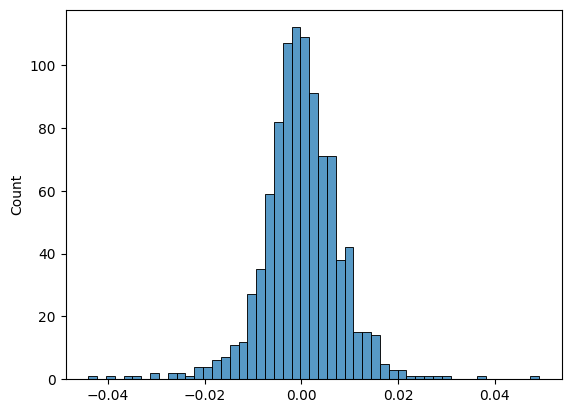

residual skew -0.17138560212715223
kurtosis of residual 4.439623000181592


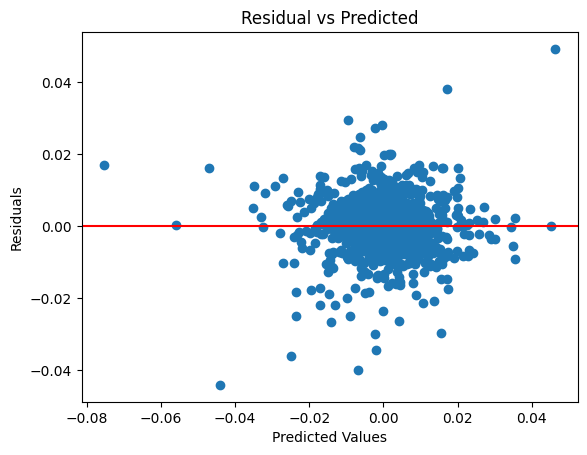

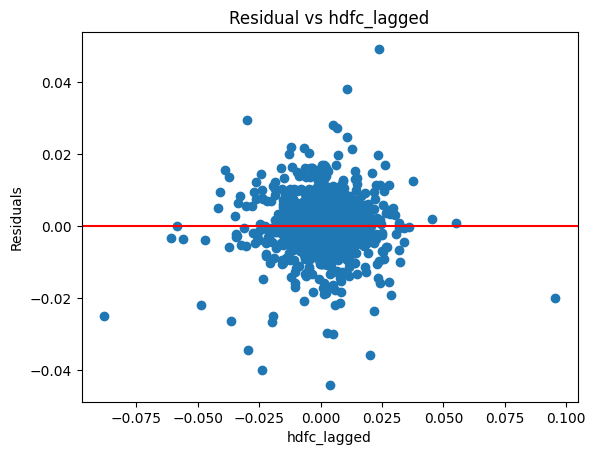

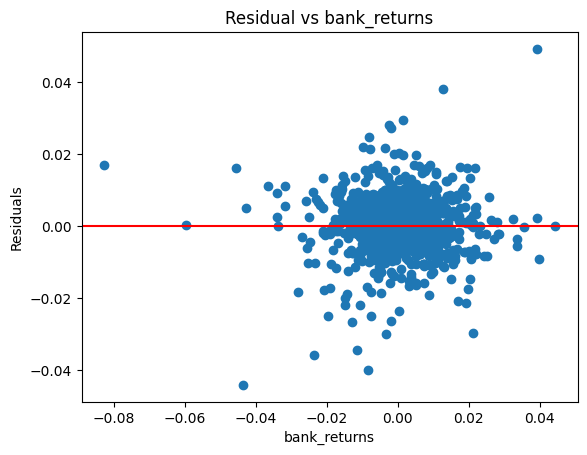

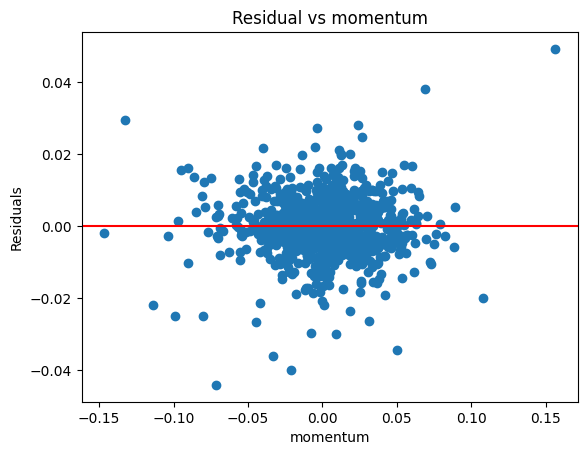

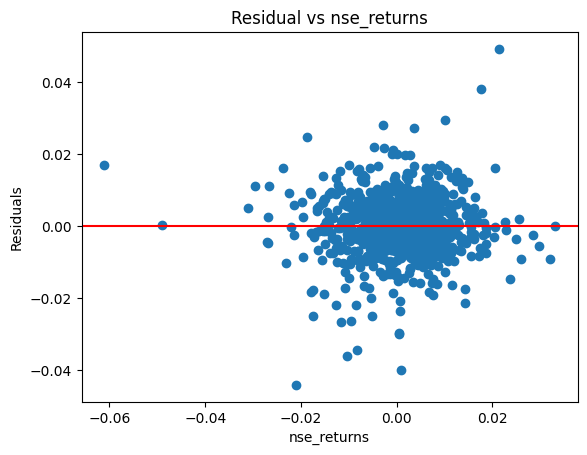

Durbin-Watson: 1.8355641678305736


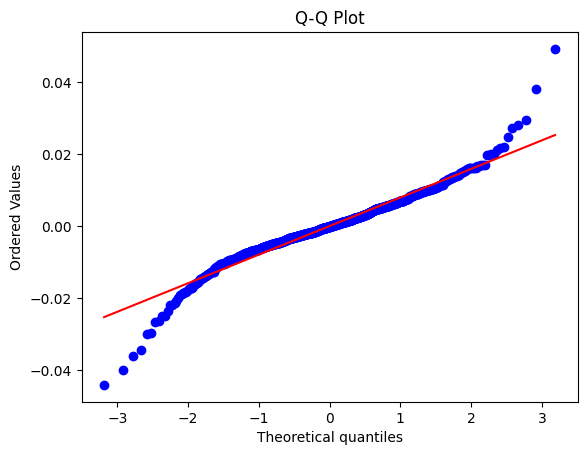

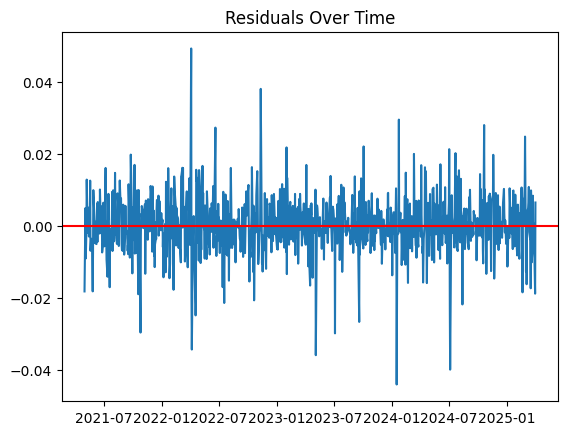

LM Stat: 6.2249268668108595
p-value: 0.18296851155956703


In [85]:
# Import
import statsmodels.api as sm

# Add constant
X_train_sm = sm.add_constant(X_train)

# Fit model
model_sm = sm.OLS(y_train, X_train_sm).fit()

# Beta / feature influences the target (HDFC returns)
coef_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': model.coef_
})

print(coef_df)

# When feature at 0 how much HDFC move / Alpha
print("Alpha =",model.intercept_)

# Residual Distribution Plot
residual = model_sm.resid
sns.histplot(residual)
plt.show()
# Skew and Kurtosis
print('residual skew',residual.skew())
print('kurtosis of residual',residual.kurt())

# Plotting predicted and residual
plt.scatter(model_sm.fittedvalues, model_sm.resid)
plt.axhline(0, color='red')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual vs Predicted')
plt.show()

# Residual vs Features
for col in X_train.columns:
    plt.scatter(X_train[col], model_sm.resid)
    plt.axhline(0, color='red')
    plt.xlabel(col)
    plt.ylabel('Residuals')
    plt.title(f'Residual vs {col}')
    plt.show()

# Error related to past or independent
from statsmodels.stats.stattools import durbin_watson
dw = durbin_watson(model_sm.resid)
print("Durbin-Watson:", dw)

# QQ plot
import scipy.stats as stats

stats.probplot(model_sm.resid, dist="norm", plot=plt)
plt.title("Q-Q Plot")
plt.show()
# Residual Over time
plt.plot(model_sm.resid)
plt.axhline(0, color='red')
plt.title("Residuals Over Time")
plt.show()

#
from statsmodels.stats.diagnostic import het_breuschpagan

bp_test = het_breuschpagan(model_sm.resid, model_sm.model.exog)

print("LM Stat:", bp_test[0])
print("p-value:", bp_test[1])